# Package requirements

In [2]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Print versions of the packages being used
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)

pandas version: 2.2.3
matplotlib version: 3.9.2


# For the time complexity comparison

/tmp/ipykernel_3400473/2607489218.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Pathway'], rotation=90, ha='right', fontsize=18)  # Set tick labels with proper alignment
/tmp/ipykernel_3400473/2607489218.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), fontsize=22)


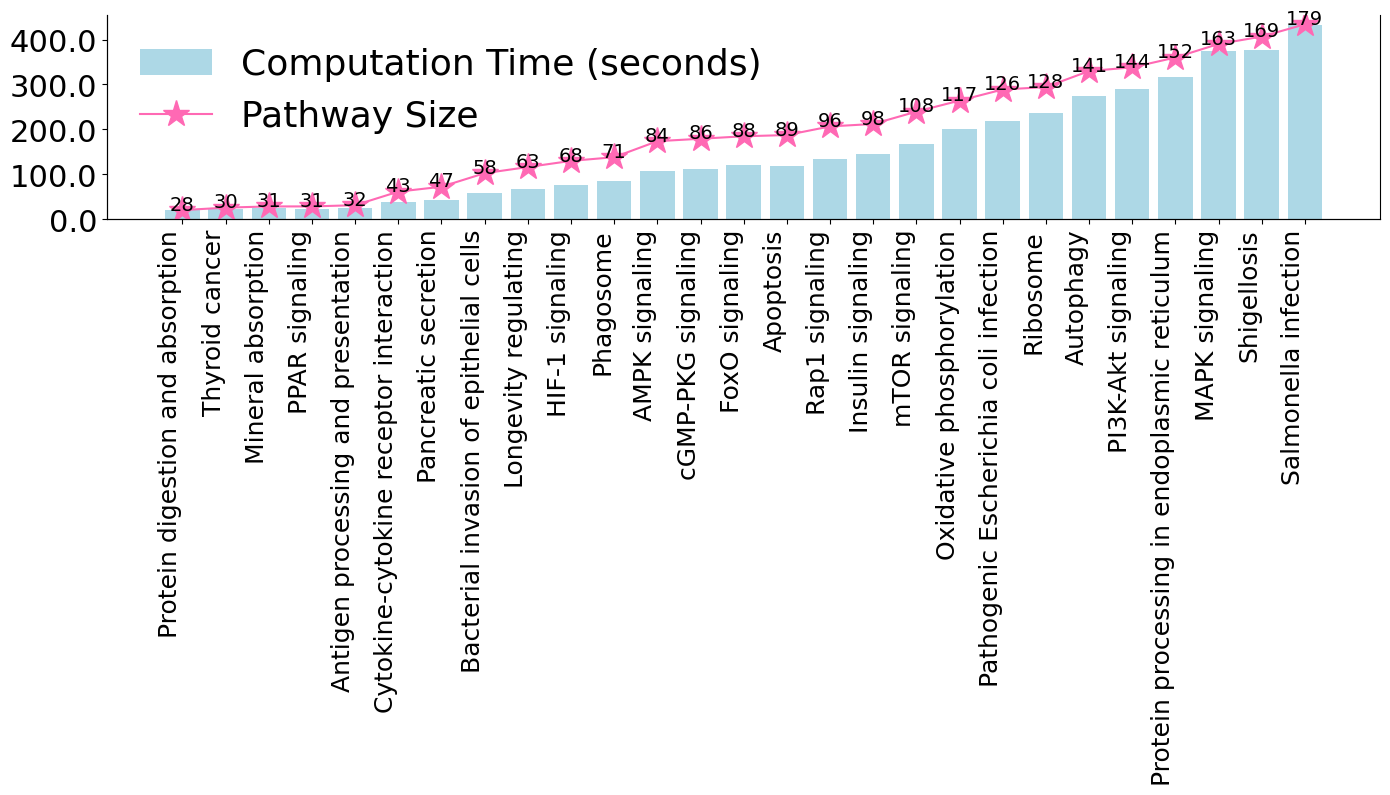

In [3]:
df = pd.read_csv('Results/pathway_comp_time_results.csv')

# Sorting the DataFrame by 'Graph Size'
df = df.sort_values(by='Pathway Size')

# Modify the pathway names to split into two lines
# Removing the word 'pathway' from the 'Pathway' column
df['Pathway'] = df['Pathway'].str.replace(' pathway', '', case=False)

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 8))

# Configure the subplot to remove the top and right borders
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)  # Remove the right border if you do not want any border for twin axes

# Bar plot for computation time
bars = ax1.bar(df['Pathway'], df['Computation Time (seconds)'], color='lightblue', label='Computation Time (seconds)')
# ax1.tick_params(axis='x', rotation=45, ha='right')
ax1.set_xticklabels(df['Pathway'], rotation=90, ha='right', fontsize=18)  # Set tick labels with proper alignment
# Set y-axis tick labels font size
ax1.set_yticklabels(ax1.get_yticks(), fontsize=22)


# Create a second y-axis for the graph size
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)  # Ensure the top spine for the second axis is also invisible
line = ax2.plot(df['Pathway'], df['Pathway Size'], color='hotpink', marker='*', markersize=20, label='Pathway Size')

# Adding labels on top of bars and points
for i, txt in enumerate(df['Pathway Size']):
    ax2.text(df['Pathway'][i], df['Pathway Size'][i], df['Pathway Size'][i], ha='center', fontsize=14)

# Adding a legend to show labels
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False, fontsize=26)

# Remove axis ticks and labels
ax1.set_ylabel('')
ax2.set_yticks([])
ax2.set_ylabel('')

# Adjust the layout
plt.subplots_adjust(bottom=0.2, top=0.9)  # Adjust the top and bottom

plt.tight_layout()  # Adjust layout to make room for rotated x-axis labels

plt.show()